In [464]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [465]:
df=pd.read_csv(r"C:\Users\Sunday Ogboi\Downloads\Portfolio\Portfolio project 01\python cleaned.csv")
df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02


In [466]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12531 non-null  float64
 6   Total Spent       12531 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
dtypes: float64(3), object(7)
memory usage: 982.6+ KB


In [467]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [468]:
df.describe()

,Price Per Unit,Quantity,Total Spent,Transaction Date
count,12575.000000,12531.000000,12531.000000,12575
mean,23.369304,5.532847,124.102394,2023-07-12 20:23:41.105368064
min,5.000000,1.000000,1.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,44.000000,2022-09-30 00:00:00
50%,23.000000,6.000000,100.000000,2023-07-13 00:00:00
75%,33.500000,8.000000,184.000000,2024-04-24 00:00:00
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00
std,10.748728,2.822615,96.099821,NaN


In [469]:
df['Year']=df['Transaction Date'].dt.year

In [470]:
Yearly_sales= df.groupby('Year').agg(
    Revenue=('Total Spent','sum'), 
    Number_of_orders = ('Transaction ID','nunique'), 
    Quantity_sold = ('Quantity','sum'), 
    Total_customers = ('Customer ID','nunique')
    ).sort_index()
Yearly_sales['Average Order Value'] = Yearly_sales['Revenue']/Yearly_sales['Number_of_orders']
Yearly_sales
# Total spent in 2025 is extremely low when compared to the rest of the year. What could have caused it

,Revenue,Number_of_orders,Quantity_sold,Total_customers,Average Order Value
Year,,,,,
2022,511383.6,4134,22950.1,25,123.701887
2023,492262.1,3987,21996.1,25,123.466792
2024,525888.6,4241,23251.6,25,124.001085
2025,25592.8,213,1134.3,25,120.153991


In [471]:
data_from_2025 = df[df['Transaction Date'].dt.year == 2025].copy().reset_index(drop=True)
data_from_2025

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Year
0,TXN_5422631,CUST_09,Milk Products,Item_2_MILK,6.5,8.0,52.0,Digital Wallet,In-store,2025-01-12,2025
1,TXN_4206593,CUST_01,Furniture,Item_21_FUR,35.0,4.0,4.0,Digital Wallet,Online,2025-01-13,2025
2,TXN_6315447,CUST_21,Patisserie,Item_7_PAT,14.0,9.0,126.0,Digital Wallet,In-store,2025-01-12,2025
3,TXN_2937307,CUST_15,Patisserie,Item_14_PAT,24.5,6.0,147.0,Cash,In-store,2025-01-06,2025
4,TXN_5115102,CUST_14,Computers and electric accessories,Item_23_CEA,38.0,4.0,152.0,Credit Card,Online,2025-01-12,2025
...,...,...,...,...,...,...,...,...,...,...,...
208,TXN_1645781,CUST_15,Butchers,Item_22_BUT,36.5,6.0,219.0,Digital Wallet,Online,2025-01-12,2025
209,TXN_4422759,CUST_21,Electric household essentials,Item_23_EHE,38.0,6.0,228.0,Cash,In-store,2025-01-06,2025
210,TXN_2363652,CUST_13,Electric household essentials,Item_11_EHE,20.0,4.0,80.0,Digital Wallet,In-store,2025-01-04,2025
211,TXN_6292699,CUST_18,Computers and electric accessories,Item_18_CEA,30.5,8.0,244.0,Credit Card,In-store,2025-01-14,2025


In [472]:
data_from_2025['Month'] = data_from_2025['Transaction Date'].dt.month

In [473]:
monthly_trends_2025 = data_from_2025.groupby('Month')['Total Spent'].sum()
print("2025 Monthly Revenue Breakdown:\n", monthly_trends_2025)

# 2025 contains only one month data. hence the low sales record
#we'll be working with the first three years(2022,2023, and 2024)

2025 Monthly Revenue Breakdown:
 Month
1    25592.8
Name: Total Spent, dtype: float64


In [474]:
df = df[df['Transaction Date'].dt.year.isin([2022, 2023, 2024])].copy().reset_index(drop=True)

In [475]:
print(df[['Price Per Unit','Quantity', 'Total Spent']].describe())

       Price Per Unit      Quantity   Total Spent
count    12362.000000  12320.000000  12320.000000
mean        23.362320      5.535536    124.150511
std         10.748273      2.822188     96.156872
min          5.000000      1.000000      1.000000
25%         14.000000      3.000000     44.000000
50%         23.000000      6.000000    100.000000
75%         33.500000      8.000000    184.250000
max         41.000000     10.000000    410.000000


In [476]:
#REVENUE ANALYSIS

In [477]:
Yearly_sales= df.groupby('Year').agg(
    Revenue=('Total Spent','sum'), 
    Number_of_orders = ('Transaction ID','nunique'), 
    Quantity_sold = ('Quantity','sum'), 
    Total_customers = ('Customer ID','nunique')
    ).sort_index()
Yearly_sales['Average Order Value'] = Yearly_sales['Revenue']/Yearly_sales['Number_of_orders']
Yearly_sales
#for three consecutive years, no significant increase in sales, number of customers remains constant. THAT'S CONCERNING

,Revenue,Number_of_orders,Quantity_sold,Total_customers,Average Order Value
Year,,,,,
2022,511383.6,4134,22950.1,25,123.701887
2023,492262.1,3987,21996.1,25,123.466792
2024,525888.6,4241,23251.6,25,124.001085


In [478]:
Yearly_sales['Revenue_growth'] = Yearly_sales['Revenue'].pct_change(fill_method=None) * 100
Yearly_sales['Revenue_growth'] = Yearly_sales['Revenue_growth'].map("{:.2f}%".format)
Yearly_sales #Though revenue fell by 3.734 percent in 2023 and regained momentum in 2024, Growth is still hovering within same space

,Revenue,Number_of_orders,Quantity_sold,Total_customers,Average Order Value,Revenue_growth
Year,,,,,,
2022,511383.6,4134,22950.1,25,123.701887,nan%
2023,492262.1,3987,21996.1,25,123.466792,-3.74%
2024,525888.6,4241,23251.6,25,124.001085,6.83%


In [479]:
df['Month'] = df['Transaction Date'].dt.month

In [480]:
monthly_sales = pd.pivot_table(df,
                              values = 'Total Spent',
                              index = 'Month',
                              columns = 'Year',
                              aggfunc='sum')
monthly_sales #accross three years, sales consistently increased in january 

Year,2022,2023,2024
Month,,,
1,53022.1,48101.1,48017.7
2,43420.7,39291.2,37228.6
3,41048.7,38623.0,42965.2
4,40503.1,39000.6,46349.3
5,40429.8,40591.4,43873.5
6,42680.2,42542.5,44805.1
7,44585.9,45740.7,41460.3
8,41402.0,38641.1,43440.5
9,46165.9,41147.8,42224.2


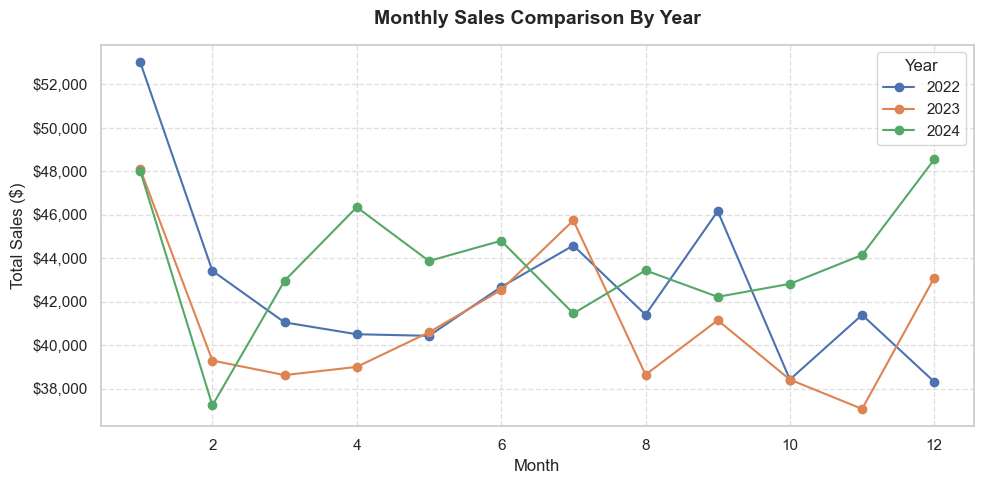

In [481]:
Montly_sales_chart= monthly_sales.plot(kind='line', figsize=(10, 5), marker='o')
plt.title('Monthly Sales Comparison By Year', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
Montly_sales_chart.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))
plt.tight_layout()
plt.show()


In [482]:
monthly_avg_order = pd.pivot_table(df,
                              values = 'Total Spent',
                              index = 'Month',
                              columns = 'Year',
                              aggfunc='count')
monthly_avg_order #January also has the highest sales average

Year,2022,2023,2024
Month,,,
1,389,371,383
2,329,312,319
3,351,309,353
4,346,323,327
5,330,334,367
6,338,349,350
7,370,374,343
8,344,317,371
9,346,333,339


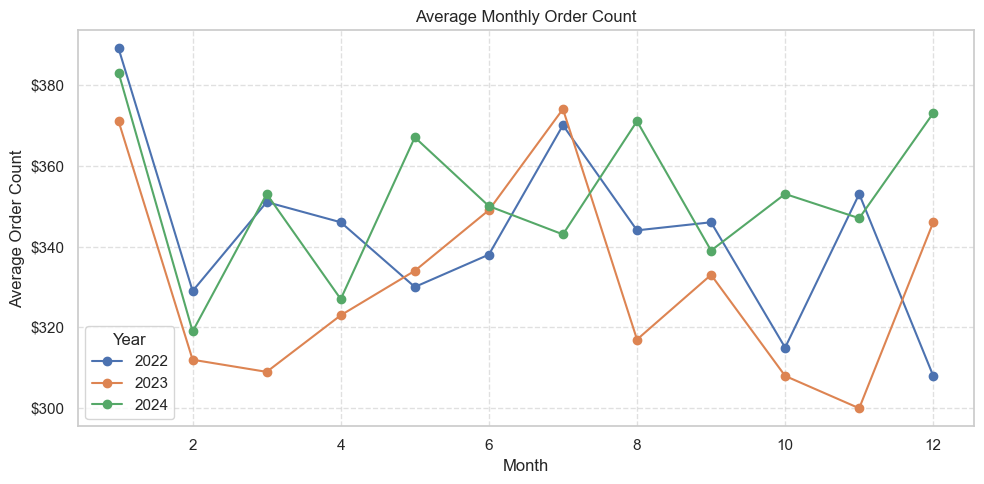

In [483]:
Monthly_order_count_chart=monthly_avg_order.plot(kind='line',figsize=(10,5),marker='o')
plt.title('Average Monthly Order Count')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Order Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
Monthly_order_count_chart.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))
plt.tight_layout()
plt.show()
#Also, order count in december have been consistently improving from 2022,through 2023 and 2024 
#the consisent increase ends in a skyrocket average number of order increase in january which suggests seasonality.
#Average number of orders consistently dropped significantly in february throughout the three years which suggests seasonal low sales.
#Conclusion: High sales season is confirmed to start from December and peaks in January
#Conclusion2:A 'W' pattern is consistent accross three years. The year starts with a peak, plummets rapidly within a month and steadily increases for the next 5 month, steadily decline for 3 to 4 months then finally rises towards the end of the year, then the

In [484]:
#PRODUCT ANALYSIS

In [485]:
Sales_by_category = df.groupby('Category').agg(
    Revenue=('Total Spent','sum'), 
    Number_of_orders = ('Transaction ID','nunique'), 
    Quantity_sold = ('Quantity','sum'), 
    Total_customers = ('Customer ID','nunique'),
    Number_of_Category_Items =('Item','nunique')
    ).sort_index()
Sales_by_category['Percentage_Of_Total_Revenue'] = (Sales_by_category['Revenue']/Sales_by_category['Revenue'].sum()) * 100
Sales_by_category['Percentage_Of_Total_Revenue'] = Sales_by_category['Percentage_Of_Total_Revenue'].map('{:.2f}%'.format)
Sales_by_category
#funiture category has the highest number of orders with 1567 orders in three years.
#food category has the highest quantity sold with 8668.4 items sold
#butchers category generated the most revenue with $204603.8 and contributes 13.38% of the total revenue in 3 years
#Although best performing Items cannot be determined based on this alone. But it's worth investigating
#Diving deep into individual items will help to understand exactly which product is doing great and which is doing the opposite

,Revenue,Number_of_orders,Quantity_sold,Total_customers,Number_of_Category_Items,Percentage_Of_Total_Revenue
Category,,,,,,
Beverages,193832.9,1541,8554.9,25,25,12.67%
Butchers,204603.8,1543,8399.3,25,25,13.38%
Computers and electric accessories,186717.1,1526,8512.6,25,25,12.21%
Electric household essentials,201223.9,1566,8575.9,25,25,13.16%
Food,191005.9,1551,8668.4,25,25,12.49%
Furniture,192929.5,1567,8657.5,25,25,12.61%
Milk Products,178387.0,1561,8572.0,25,25,11.66%
Patisserie,180834.2,1507,8257.2,25,25,11.82%


In [486]:
All_items_sales = df.groupby(['Category','Item']).agg(
    Revenue=('Total Spent','sum'), 
    Number_of_orders = ('Transaction ID','nunique'), 
    Quantity_sold = ('Quantity','sum')).sort_values(by='Revenue', ascending=False).reset_index()

In [487]:
Rev_sort = All_items_sales.sort_values(by='Revenue', ascending=False)
top_5_rev = Rev_sort.head(5).copy()
least_5_rev = Rev_sort.tail(5).copy()

by_qty = All_items_sales.sort_values(by='Quantity_sold', ascending=False)
top_5_qty = by_qty.head(5).copy()
least_5_qty = by_qty.tail(5).copy()

top_5_rev['Performance_Metric'] = 'Top 5 (Revenue)'
least_5_rev['Performance_Metric'] = 'Least 5 (Revenue)'
top_5_qty['Performance_Metric'] = 'Top 5 (Quantity Sold)'
least_5_qty['Performance_Metric'] = 'Least 5 (Quantity Sold)'

summary_table_top_least = pd.concat([top_5_rev, least_5_rev, top_5_qty, least_5_qty])

cols = ['Performance_Metric', 'Category', 'Item', 'Revenue', 'Quantity_sold', 'Number_of_orders']
summary_table_top_least = summary_table_top_least[cols].reset_index(drop=True)
summary_table_top_least

#Top 5 performers and least 5 performers by both quantity and revenue are distributed randomly between the different categories.
#This shows no pattern in performance by category Performance is least affected by category item type
#Bottom 'Quantity_sold performance noticeably has a very 'number of orders' suggesting it's not a product in high demand.
#Item Item_1_CEA has a prominent higher quantities sild, yet generated less revenue. 
#This is suggests that price per unit also affects revenue generated by individual Items.


#Item_25_FUR generated the most revenue with $25,207.8 while Item_3_EHE generated the least revenue with $224.0
#Item_2_BEV has the highest sales quantity with 706.8 units sold while Item_21_PAT has the lowest quantity sold with 23.0 units sold
#This descrepancy in quantity sold vs revenue generated between the high performers could be due to the either price differences between the two Items or the discount promotion that tanked revenue

,Performance_Metric,Category,Item,Revenue,Quantity_sold,Number_of_orders
0,Top 5 (Revenue),Furniture,Item_25_FUR,25207.8,647.8,119
1,Top 5 (Revenue),Electric household essentials,Item_25_EHE,25163.9,643.9,111
2,Top 5 (Revenue),Butchers,Item_25_BUT,22207.5,567.5,104
3,Top 5 (Revenue),Furniture,Item_24_FUR,21720.5,584.0,115
4,Top 5 (Revenue),Food,Item_25_FOOD,21303.3,543.3,98
5,Least 5 (Revenue),Food,Item_1_FOOD,722.0,150.0,29
6,Least 5 (Revenue),Computers and electric accessories,Item_4_CEA,636.5,67.0,12
7,Least 5 (Revenue),Computers and electric accessories,Item_1_CEA,622.0,130.0,26
8,Least 5 (Revenue),Beverages,Item_5_BEV,517.0,47.0,7
9,Least 5 (Revenue),Electric household essentials,Item_3_EHE,224.0,28.0,5


In [488]:
price_list = df_filtered_by_items.groupby(["Category", "Price Per Unit"])["Item"].first().reset_index()
df['Item'] = df['Item'].astype(str).replace('nan', np.nan)

In [489]:
pd.merge(summary_table_top_least, price_list, on=['Category', 'Item'], how='left')
#Top revenue generator has a price per unit of $41.0 while the top quantity sold has a price per unit of $6.5.This explains why the top quantity sold Item is not the top revenue generator
#the revenue generated by 'Item_4_CEA' and 'Item_1_CEA generated' are very close despite having a significantly large variace in quantity sold

,Performance_Metric,Category,Item,Revenue,Quantity_sold,Number_of_orders,Price Per Unit
0,Top 5 (Revenue),Furniture,Item_25_FUR,25207.8,647.8,119,41.0
1,Top 5 (Revenue),Electric household essentials,Item_25_EHE,25163.9,643.9,111,41.0
2,Top 5 (Revenue),Butchers,Item_25_BUT,22207.5,567.5,104,41.0
3,Top 5 (Revenue),Furniture,Item_24_FUR,21720.5,584.0,115,39.5
4,Top 5 (Revenue),Food,Item_25_FOOD,21303.3,543.3,98,41.0
5,Least 5 (Revenue),Food,Item_1_FOOD,722.0,150.0,29,5.0
6,Least 5 (Revenue),Computers and electric accessories,Item_4_CEA,636.5,67.0,12,9.5
7,Least 5 (Revenue),Computers and electric accessories,Item_1_CEA,622.0,130.0,26,5.0
8,Least 5 (Revenue),Beverages,Item_5_BEV,517.0,47.0,7,11.0
9,Least 5 (Revenue),Electric household essentials,Item_3_EHE,224.0,28.0,5,8.0


In [490]:
#Year On Year Analysis

In [491]:
product_year = pd.pivot_table(df,
                              values ='Total Spent',
                              index = 'Category',
                              columns='Year',
                              fill_value=0,
                              aggfunc='sum')
product_year = product_year.loc[product_year.sum(axis=1).sort_values(ascending=False).index]
product_year

Year,2022,2023,2024
Category,,,
Butchers,79496.6,58953.3,66153.9
Electric household essentials,71605.0,64007.6,65611.3
Beverages,63680.3,55810.6,74342.0
Furniture,60701.7,63516.2,68711.6
Food,57197.2,67754.6,66054.1
Computers and electric accessories,57270.5,63006.7,66439.9
Patisserie,62830.6,56344.5,61659.1
Milk Products,58601.7,62868.6,56916.7


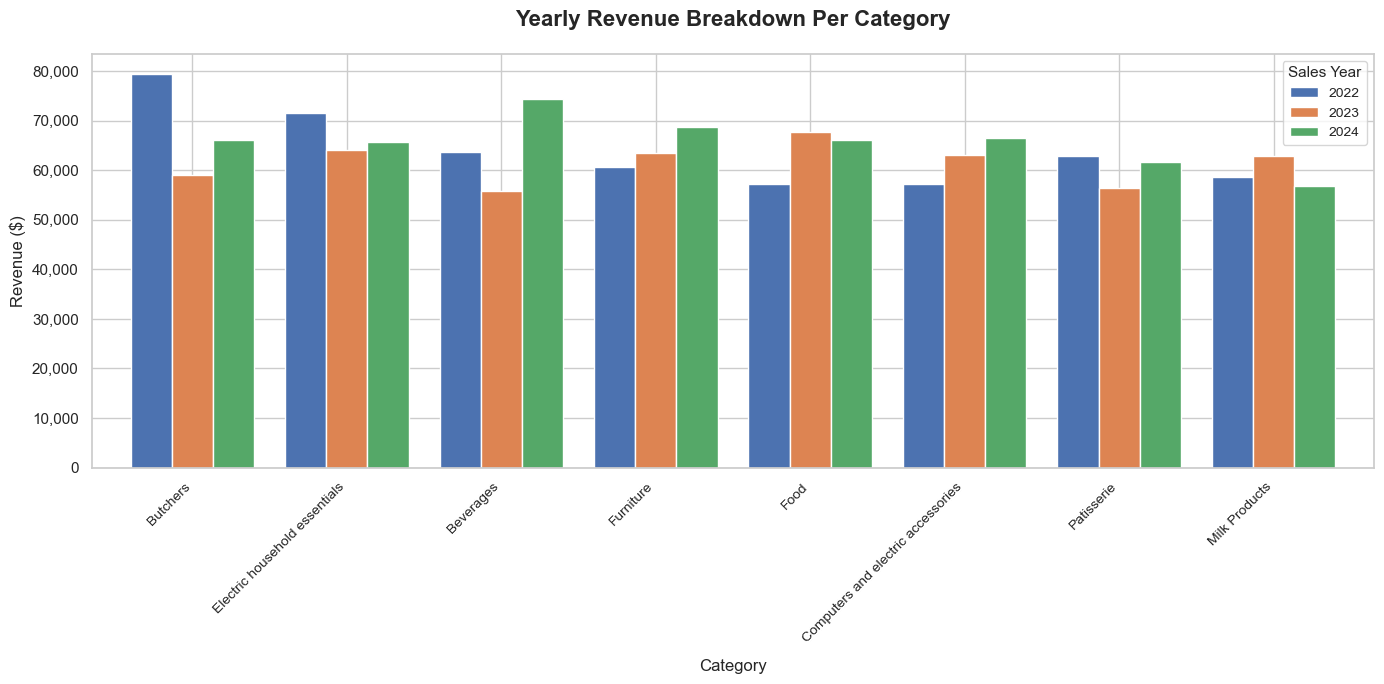

In [492]:
sns.set_theme(style="whitegrid")
ax = product_year.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('Yearly Revenue Breakdown Per Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12, labelpad=10)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Sales Year', title_fontsize='11', fontsize='10')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.tight_layout()
plt.show()


In [493]:
YOY_sales = df.groupby(['Item', 'Year']).agg(Revenue=('Total Spent', 'sum')).reset_index()
summary_with_year = pd.merge(
    summary_table_top_least[['Performance_Metric', 'Category', 'Item']], 
    YOY_sales,
    on='Item',
    how='inner')
pivot_ranked = pd.pivot_table(
    summary_with_year,
    values='Revenue',
    index=['Performance_Metric', 'Category', 'Item'], 
    columns='Year',
    aggfunc='sum',
    fill_value=0)
pivot_ranked

#In 2022, Item_3_EHE generated 0 revenue, This means that 0 units was sold. This could be due to it not being in stock, making it a relatively new product.
#It could also be due to zero demand despite being in stock. This could be due to poor marketing
#But to fully understand why the Item generated 0 revenue, further analysis is required for stock and marketing history(a different data is needed)

Year                                                                       2022  \
Performance_Metric      Category                           Item                   
Least 5 (Quantity Sold) Beverages                          Item_13_BEV    391.0   
                                                           Item_5_BEV     187.0   
                        Electric household essentials      Item_3_EHE       0.0   
                        Furniture                          Item_13_FUR    276.0   
                        Patisserie                         Item_21_PAT    350.0   
Least 5 (Revenue)       Beverages                          Item_5_BEV     187.0   
                        Computers and electric accessories Item_1_CEA     292.0   
                                                           Item_4_CEA     161.5   
                        Electric household essentials      Item_3_EHE       0.0   
                        Food                               Item_1_FOOD    262.0   
Top 5 (Quantity Sold)   Beverages                          Item_2_BEV    1785.0   
                        Computers and electric accessories Item_19_CEA   4567.8   
                        Furniture                          Item_25_FUR   8666.0   
                        Milk Products                      Item_16_MILK  5860.8   
                                                           Item_19_MILK  6540.4   
Top 5 (Revenue)         Butchers                           Item_25_BUT   7510.0   
                        Electric household essentials      Item_25_EHE   8913.8   
                        Food                               Item_25_FOOD  6456.8   
                        Furniture                          Item_24_FUR   6269.8   
                                                           Item_25_FUR   8666.0   

Year                                                                       2023  \
Performance_Metric      Category                           Item                   
Least 5 (Quantity Sold) Beverages                          Item_13_BEV     69.0   
                                                           Item_5_BEV     242.0   
                        Electric household essentials      Item_3_EHE     184.0   
                        Furniture                          Item_13_FUR    460.0   
                        Patisserie                         Item_21_PAT    105.0   
Least 5 (Revenue)       Beverages                          Item_5_BEV     242.0   
                        Computers and electric accessories Item_1_CEA      75.0   
                                                           Item_4_CEA     209.0   
                        Electric household essentials      Item_3_EHE     184.0   
                        Food                               Item_1_FOOD    335.0   
Top 5 (Quantity Sold)   Beverages                          Item_2_BEV    1293.5   
                        Computers and electric accessories Item_19_CEA   5637.3   
                        Furniture                          Item_25_FUR   7306.0   
                        Milk Products                      Item_16_MILK  7407.5   
                                                           Item_19_MILK  6468.0   
Top 5 (Revenue)         Butchers                           Item_25_BUT   6120.2   
                        Electric household essentials      Item_25_EHE   7757.0   
                        Food                               Item_25_FOOD  8737.5   
                        Furniture                          Item_24_FUR   6833.5   
                                                           Item_25_FUR   7306.0   

Year                                                                       2024  
Performance_Metric      Category                           Item                  
Least 5 (Quantity Sold) Beverages                          Item_13_BEV    368.0  
                                                           Item_5_BEV      88.0  
                  

In [494]:
#Customer Analysis

In [495]:
print("Revenue Skewness:", df['Total Spent'].skew())
print("Revenue Kurtosis:", df['Total Spent'].kurt())
#sales is left skewed(0.837)This sugests that most customers purchase premium
#kurtosis is negative and very close to 0 (-0.095). This suggests total spent is balanced accross customers

Revenue Skewness: 0.8373465913071657
Revenue Kurtosis: -0.09530992136152738


In [496]:
Customer_Metrics = df.groupby('Customer ID').agg(Total_Quantity = ('Quantity','sum'),
                                                 Total_Revenue = ('Total Spent','sum'),
                                                Total_Orders=('Transaction ID','nunique'))
Customer_Metrics['Average_Order_Value'] = (Customer_Metrics['Total_Revenue']/Customer_Metrics['Total_Orders']).map(lambda x: f"${x:.2f}")
Customer_Metrics
#Average order values for all customers fall withing the same range.

,Total_Quantity,Total_Revenue,Total_Orders,Average_Order_Value
Customer ID,,,,
CUST_01,2740.9,58118.4,496,$117.17
CUST_02,2693.3,61325.8,481,$127.50
CUST_03,2608.4,60068.4,456,$131.73
CUST_04,2610.4,60624.4,464,$130.66
CUST_05,2920.0,66631.5,540,$123.39
CUST_06,2568.1,57257.1,472,$121.31
CUST_07,2671.6,59832.6,482,$124.13
CUST_08,3011.0,66825.5,526,$127.04
CUST_09,2759.5,60672.5,510,$118.97


In [497]:
Customer_Revenue= df.groupby('Customer ID')['Total Spent'].sum().sort_values(ascending=False)

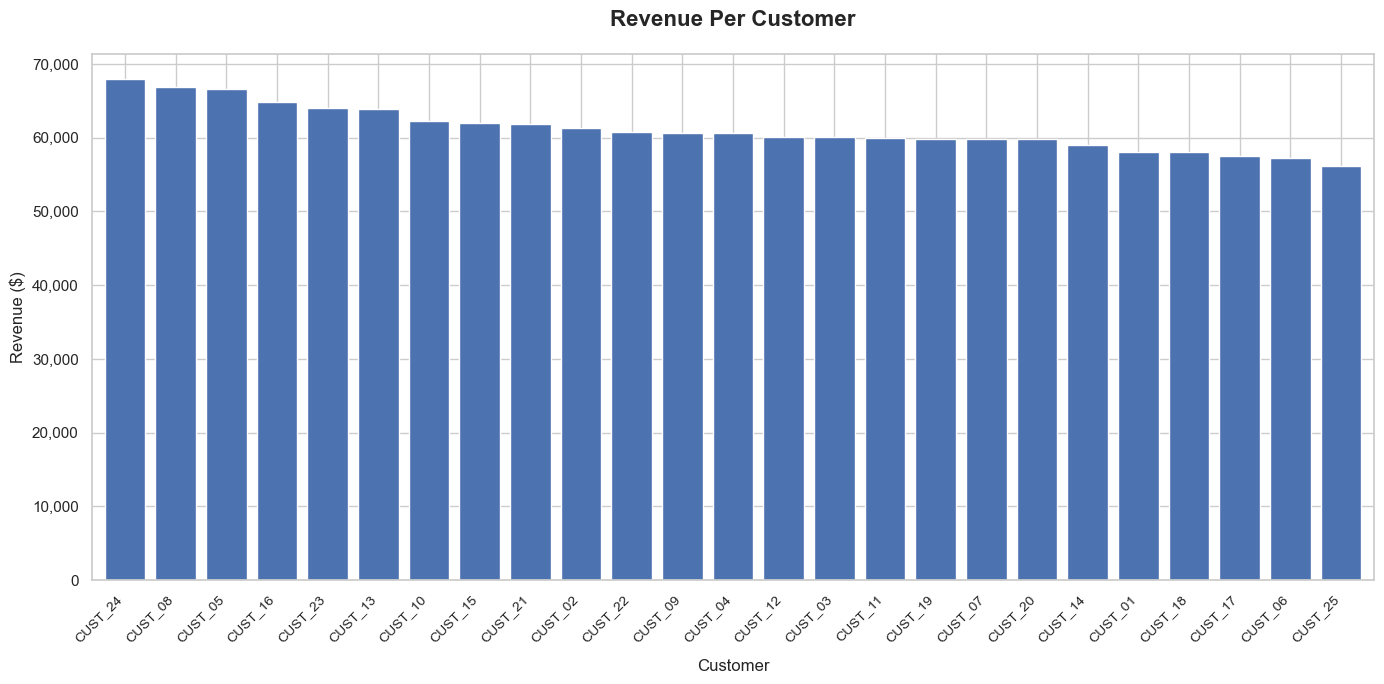

In [498]:
Customer_Revenue_trend = Customer_Revenue.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('Revenue Per Customer', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Customer', fontsize=12, labelpad=10)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
Customer_Revenue_trend.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.tight_layout()
plt.show()

In [499]:
Customer_frequency = df.groupby('Customer ID')['Transaction ID'].nunique().sort_values(ascending = False)
Customer_frequency

Customer ID
CUST_05    540
CUST_24    534
CUST_08    526
CUST_13    524
CUST_15    510
CUST_09    510
CUST_16    508
CUST_23    507
CUST_18    498
CUST_01    496
CUST_20    495
CUST_11    494
CUST_10    494
CUST_22    494
CUST_21    489
CUST_12    486
CUST_07    482
CUST_02    481
CUST_17    481
CUST_19    480
CUST_14    474
CUST_06    472
CUST_25    467
CUST_04    464
CUST_03    456
Name: Transaction ID, dtype: int64

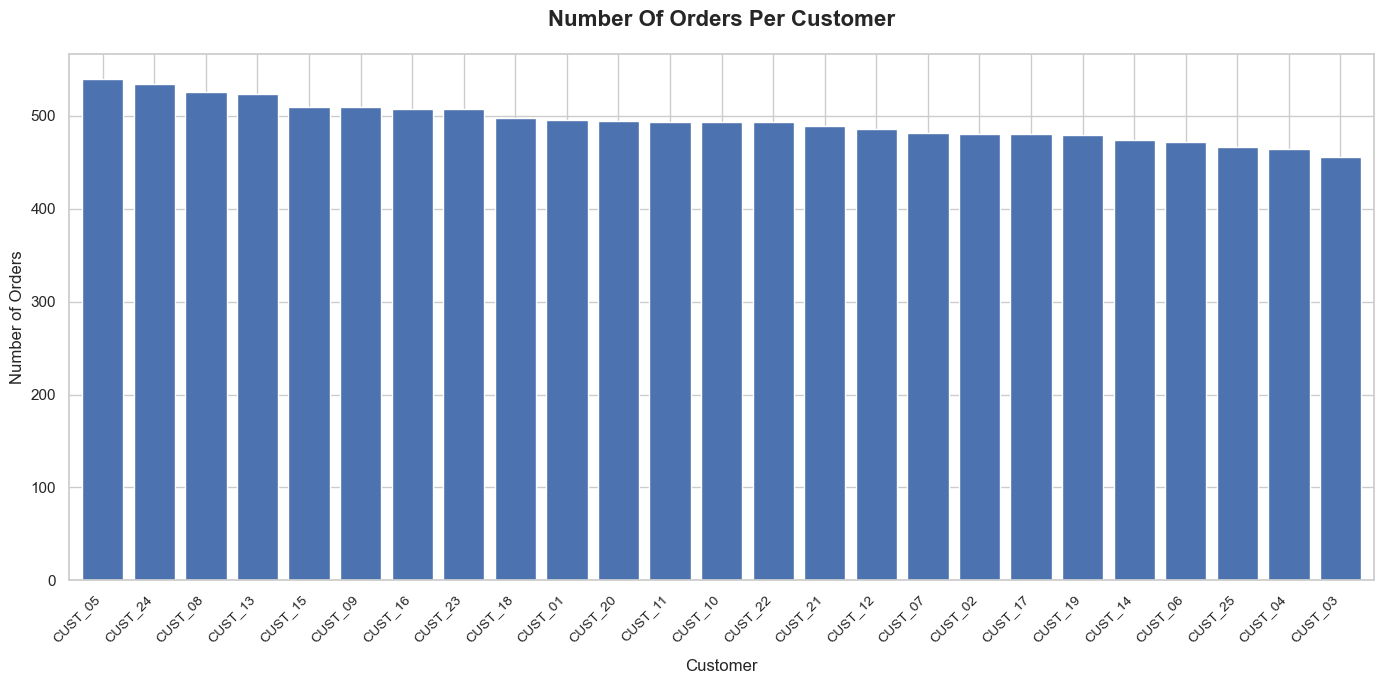

In [500]:
Customer_frequency_trend = Customer_frequency.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('Number Of Orders Per Customer', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Customer', fontsize=12, labelpad=10)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
Customer_frequency_trend.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.tight_layout()
plt.show()

In [501]:
customer_year = pd.pivot_table(df,
                               index='Customer ID',
                               columns='Year',
                               aggfunc='sum',
                               values='Total Spent',
                               fill_value=0)
customer_year = customer_year.loc[customer_year.mean(axis=1).sort_values(ascending=False).index]
customer_year
#Revenue is within the same range among all customers  across the three years
#A customer that joined later(eg,2023)is not in the same category as a customer that joined in 2022 if the total revenue for each customer are in the same range

Year,2022,2023,2024
Customer ID,,,
CUST_24,24186.7,18498.3,25284.8
CUST_08,19841.3,23233.9,23750.3
CUST_05,21488.6,22312.7,22830.2
CUST_16,20314.9,21745.5,22814.0
CUST_23,23847.4,18888.7,21336.4
CUST_13,20043.1,21295.6,22549.1
CUST_10,20533.2,20018.7,21734.0
CUST_15,20101.3,20378.2,21528.5
CUST_21,18124.7,21636.9,22120.8


In [502]:
first_purchase = df.groupby('Customer ID')['Transaction Date'].min()
first_purchase
#24 out of 25 customer's first purchase based on this data are within the first 8 days of the first year (Large percentage purchased within the first 3 days)with the exeption of CUST_02
#This means that all customers are either existing customers prior to the beginning of this data or they are standby customers even before the company kicked off sales(The later is less likely).
#To dive deeper into this, data with ALL sales history is needed. And if this data contains all sales history(no prior sales occured), then the later above is true.

Customer ID
CUST_01   2022-01-01
CUST_02   2022-01-17
CUST_03   2022-01-08
CUST_04   2022-01-02
CUST_05   2022-01-03
CUST_06   2022-01-01
CUST_07   2022-01-04
CUST_08   2022-01-03
CUST_09   2022-01-03
CUST_10   2022-01-02
CUST_11   2022-01-01
CUST_12   2022-01-01
CUST_13   2022-01-04
CUST_14   2022-01-07
CUST_15   2022-01-01
CUST_16   2022-01-01
CUST_17   2022-01-01
CUST_18   2022-01-02
CUST_19   2022-01-01
CUST_20   2022-01-03
CUST_21   2022-01-05
CUST_22   2022-01-01
CUST_23   2022-01-02
CUST_24   2022-01-01
CUST_25   2022-01-03
Name: Transaction Date, dtype: datetime64[ns]

In [503]:
#Recommendation: All existing customers are loyal and grounded customers. The company should focus on acquiring more customers to drive growth.